# Entrega 2 · Análisis exploratorio del proyecto ATP

**Grupo 5K10-05 · Ciencia de Datos · UTN FRM · 23 de septiembre de 2026**

Este notebook está ejecutado y conserva sus resultados. Recorre el Silver real,
audita sus faltantes, resuelve cuatro fichas con el método de la cátedra y deja
las columnas candidatas para la Entrega 3. Los gráficos y las tablas se exportan
a `resultados/` al ejecutar; no se necesita descargar datos ni levantar Airflow.

## 0. Qué cambió y qué queremos responder

**Corrección informada de la Entrega 1:** se añadió `build_player_dataset`.
El Silver ahora incluye `atp_jugadores.csv`, con **una fila por jugador**; el
consolidado de partidos se conserva como insumo. No se presupone que ésta sea
toda la devolución docente: es la corrección comunicada en el proyecto.

Se conservan las tres preguntas:
1. ¿Existen estilos de juego diferenciables según saque y resto?
2. ¿Hay estilos con mayor rendimiento y cómo depende de la superficie?
3. ¿El emparejamiento de estilos aporta a predecir el ganador por encima del ranking?

**Dos unidades, dos propósitos:** el dataset principal y el EDA de perfiles
siguen teniendo una fila por jugador. El clustering es no supervisado: todavía
no existe una columna `estilo` verdadera y no se inventa una para esta entrega.
Para la tercera pregunta se construye una tabla **auxiliar** de partidos A/B
con objetivo concreto `gana_a` (1 ganó A, 0 ganó B). Esa tabla no reemplaza al Silver.
La distribución del objetivo se mide allí. Cambiar a un objetivo artificial
como “buen jugador” alteraría la pregunta original.

**Alcance:** esta entrega prepara decisiones; no entrena clusters ni afirma
mejoras predictivas. La comparación entre modelos corresponde a Entrega 3.

In [1]:
from pathlib import Path
import hashlib, json, platform, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

actual = Path.cwd().resolve()
opciones = [actual, *actual.parents, actual / 'Proyecto']
ROOT = next(p for p in opciones if (p / 'airflow-atp/include/output/silver/atp_jugadores.csv').exists())
BASE = ROOT / 'entrega2'
OUT = BASE / 'resultados'
FIG = OUT / 'graficos'
FIG.mkdir(parents=True, exist_ok=True)
SILVER = ROOT / 'airflow-atp/include/output/silver'
RUTAS = {'jugadores': SILVER / 'atp_jugadores.csv', 'partidos': SILVER / 'partidos_consolidado.csv'}
HUELLAS = {k: hashlib.sha256(p.read_bytes()).hexdigest() for k, p in RUTAS.items()}
SEMILLA, CORTE = 42, 2023
MIN_PARTIDOS, MIN_PUNTOS, MIN_COBERTURA = 20, 500, .80
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 18)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams.update({'figure.figsize': (9, 4.2), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.grid': True, 'grid.alpha': .16,
    'font.size': 10, 'savefig.facecolor': 'white'})
AZUL, VERDE, ROJO = '#2563eb', '#0f766e', '#b91c1c'

# Muestra una conclusión en formato Markdown.
def texto(s): display(Markdown(s))
# Guarda una tabla y, si corresponde, la muestra.
def exportar(tabla, nombre, mostrar=True):
    tabla.to_csv(OUT / f'{nombre}.csv', index=False, encoding='utf-8-sig')
    if mostrar: display(tabla)
# Guarda y muestra el gráfico activo.
def grafico(nombre):
    plt.tight_layout()
    plt.savefig(FIG / f'{nombre}.png', dpi=160, bbox_inches='tight')
    plt.show()
# Divide solamente cuando el denominador es positivo.
def division(n, d): return n / d.where(d > 0)

df_csv = pd.read_csv(RUTAS['jugadores'], dtype={'id-jugador': 'string'})
df = df_csv.copy()
df['fecha-nacimiento'] = pd.to_datetime(df['fecha-nacimiento'], errors='coerce')
for c in ['mano-dominante', 'tipo-reves', 'pais']:
    df[c] = df[c].astype('category')
partidos = pd.read_csv(RUTAS['partidos'], dtype={'winner_id':'string', 'loser_id':'string'}, low_memory=False)
partidos['fecha'] = pd.to_datetime(partidos['fecha'], errors='coerce')
partidos['anio'] = partidos['fecha'].dt.year
assert df['id-jugador'].notna().all() and df['id-jugador'].is_unique
assert partidos['id_partido'].is_unique
texto(f'**Datos locales:** {len(df):,} jugadores × {df.shape[1]} columnas; '
      f'{len(partidos):,} partidos × {partidos.shape[1]} columnas. '
      f'Fechas: {partidos.fecha.min():%Y-%m-%d} a {partidos.fecha.max():%Y-%m-%d}.')

**Datos locales:** 1,414 jugadores × 89 columnas; 77,474 partidos × 55 columnas. Fechas: 2000-01-03 a 2025-12-22.

## 1. Perfil completo: tamaño, tipos, nulos, constantes y duplicados

`id-jugador` es un identificador, aunque algunos IDs parezcan números. Los conteos
pueden leerse como `float` porque provienen de sumas con faltantes; eso no los
convierte en variables continuas del dominio. `fecha-nacimiento` se convierte
explícitamente en fecha; un CSV no conserva tipos de pandas.

,tipo,columnas
0,float64,68
1,int64,15
2,category,3
3,string,1
4,str,1
5,datetime64[us],1


,columna,tipo_csv,tipo_analitico,nulos,pct_nulos,valores_distintos,constante_o_vacia,asimetria
6,tipo-reves,str,category,521,36.8458,2,False,NaN
7,año-profesional,float64,float64,468,33.0976,40,False,0.1510
3,altura-cm,float64,float64,266,18.8119,18,False,0.1593
4,peso-kg,float64,float64,251,17.7511,45,False,0.1982
5,mano-dominante,str,category,136,9.6181,3,False,NaN
2,fecha-nacimiento,str,datetime64[us],9,0.6365,1327,False,NaN
8,pais,str,category,1,0.0707,107,False,NaN
0,id-jugador,string,string,0,0.0000,1414,False,NaN
1,nombre-jugador,str,str,0,0.0000,1414,False,NaN
9,aces-totales,float64,float64,0,0.0000,619,False,4.5382


**Duplicados de clave: 0. Duplicados de fila completa: 0. Columnas 100% nulas: 0. Constantes: ['titulos-1000-grass'].**

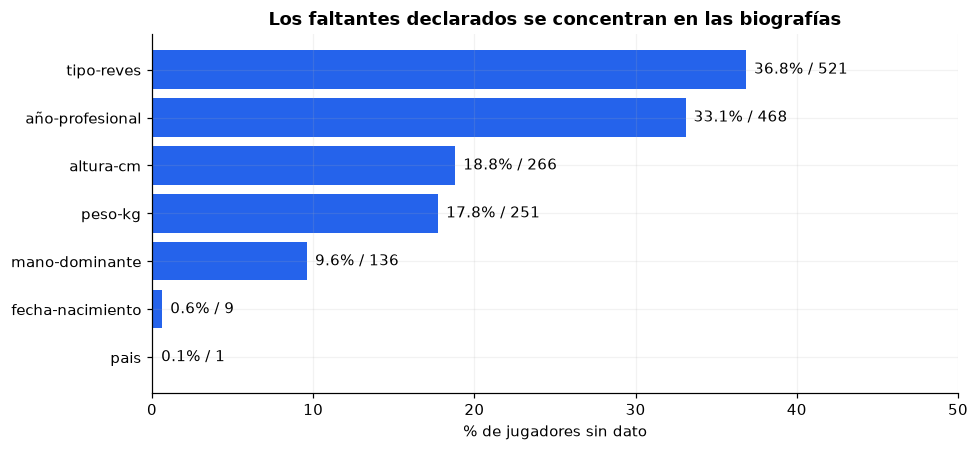

In [2]:
perfil = pd.DataFrame({'columna': df.columns, 'tipo_csv': df_csv.dtypes.astype(str).values,
    'tipo_analitico': df.dtypes.astype(str).values, 'nulos': df.isna().sum().values,
    'pct_nulos': 100 * df.isna().mean().values,
    'valores_distintos': df.nunique(dropna=True).values})
perfil['constante_o_vacia'] = perfil['valores_distintos'] <= 1
perfil['asimetria'] = perfil['columna'].map(df.select_dtypes('number').skew())
exportar(perfil, 'perfil_89_columnas', False)
display(pd.DataFrame({'tipo': df.dtypes.astype(str).value_counts().index,
                     'columnas': df.dtypes.astype(str).value_counts().values}))
display(perfil.sort_values('pct_nulos', ascending=False).head(10))
constantes = perfil.loc[perfil.constante_o_vacia, 'columna'].tolist()
texto(f'**Duplicados de clave: {df["id-jugador"].duplicated().sum()}. '
      f'Duplicados de fila completa: {df.duplicated().sum()}. '
      f'Columnas 100% nulas: {df.isna().all().sum()}. Constantes: {constantes}.**')
assert (df['partidos-totales'] == df['victorias-totales'] + df['derrotas-totales']).all()
for m in ['partidos', 'victorias', 'derrotas']:
    assert np.allclose(df[f'{m}-totales'], df[[f'{m}-{s}' for s in ['cemento','clay','grass']]].sum(axis=1))
fig, ax = plt.subplots()
nulos = perfil.query('nulos > 0').sort_values('pct_nulos')
ax.barh(nulos.columna, nulos.pct_nulos, color=AZUL)
for i,v in enumerate(nulos.pct_nulos): ax.text(v+.5, i, f'{v:.1f}% / {int(nulos.iloc[i].nulos)}', va='center')
ax.set(xlabel='% de jugadores sin dato', title='Los faltantes declarados se concentran en las biografías', xlim=(0,50))
grafico('01_nulos')

**Decisiones y causa de los tres faltantes principales:**
- `tipo-reves`: la biografía no informa el revés. Es desconocido; no significa “sin revés”.
- `año-profesional`: el archivo auxiliar omite el año o trae 0 y el código lo transforma en nulo.
- `altura-cm`: la biografía no informa altura o trae 0 y la limpieza lo transforma en nulo.

No podemos asegurar por qué el proveedor no recolectó cada valor. Sí podemos
localizar la falta en la fuente y el tratamiento en `cargar_informacion_jugadores`.
`peso-kg` además se anula fuera del rango 40–200 del código existente.
No se imputan datos biográficos para medir las hipótesis: se informa la cantidad
de casos completos. Para modelar, las imputaciones se ajustarán solo en entrenamiento.

`titulos-1000-grass` es constante en este archivo: sale de los modelos por no
aportar variación. Un cero en títulos puede significar que no ganó títulos;
un cero en puntos de saque requiere otra comprobación.

## 2. Auditar los ceros y reconstruir tasas comparables

El código de Silver hace `groupby(...).sum()`: si todas las observaciones son
nulas puede producir 0. Por eso “0% de nulos en aces” no garantiza cobertura.
Reconstruimos cada tasa desde los partidos: sumamos numerador y denominador
**solo sobre las mismas observaciones válidas**. No modificamos el Silver.

También podemos derivar rendimiento al resto usando las estadísticas del rival:
puntos ganados al resto = puntos de saque del rival − puntos que ganó al saque.
Esto aporta información de devolución; no mide desplazamiento, winners ni
errores no forzados y no alcanza para etiquetar automáticamente “defensor”.

In [3]:
superficie_valida = partidos.surface.isin(['Hard', 'Clay', 'Grass'])
p = partidos.loc[superficie_valida].copy()
exportar(pd.DataFrame([
    {'regla':'Consolidado original', 'filas':len(partidos)},
    {'regla':'Carpet excluido', 'filas':int(partidos.surface.eq('Carpet').sum())},
    {'regla':'Superficie faltante o no reconocida', 'filas':int((~superficie_valida & ~partidos.surface.eq('Carpet')).sum())},
    {'regla':'Partidos para participaciones', 'filas':len(p)},
]), 'trazabilidad_superficies')

# Unifica las columnas del ganador o del perdedor.
def lado(prefijo, rival, persona, gano):
    z = p[['id_partido', 'fecha', 'anio', 'surface', 'tourney_level', 'score']].copy()
    z['id-jugador'] = p[f'{persona}_id']
    z['altura'] = pd.to_numeric(p[f'{persona}_ht'], errors='coerce')
    z['mano'] = p[f'{persona}_hand']
    z['victoria'] = gano
    z['partidos'] = 1
    for s in ['ace','df','svpt','1stIn','1stWon','2ndWon','bpSaved','bpFaced']:
        z[s] = pd.to_numeric(p[f'{prefijo}_{s}'], errors='coerce')
    for s in ['svpt','1stWon','2ndWon','bpSaved','bpFaced']:
        z[f'rival_{s}'] = pd.to_numeric(p[f'{rival}_{s}'], errors='coerce')
    return z

largo = pd.concat([lado('w','l','winner',1), lado('l','w','loser',0)], ignore_index=True)
assert len(largo) == 2 * len(p)
RATIOS = {
    'tasa_aces': ('ace', 'svpt'),
    'tasa_dobles_faltas': ('df', 'svpt'),
    'primer_saque_dentro': ('1stIn', 'svpt'),
    'efectividad_primero': ('1stWon', '1stIn'),
    'efectividad_segundo': ('2ndWon', 'segundos_intentos'),
    'bp_salvados': ('bpSaved', 'bpFaced'),
    'puntos_ganados_resto': ('resto_ganados', 'rival_svpt'),
    'bp_convertidos': ('quiebres', 'rival_bpFaced'),
}
SIGNIFICADOS = {
    'tasa_aces':'Aces / puntos de saque: frecuencia de puntos ganados directamente con el servicio.',
    'tasa_dobles_faltas':'Dobles faltas / puntos de saque: frecuencia de errores de ambos servicios.',
    'primer_saque_dentro':'Primeros saques dentro / puntos de saque: regularidad del primer servicio.',
    'efectividad_primero':'Puntos ganados con primer saque / primeros saques dentro: éxito cuando entra.',
    'efectividad_segundo':'Puntos ganados con segundo saque / (puntos de saque - primeros dentro). Incluye dobles faltas entre intentos.',
    'bp_salvados':'Break points salvados / enfrentados: proporción de oportunidades de quiebre evitadas al sacar.',
    'puntos_ganados_resto':'(Puntos de saque del rival - primeros y segundos ganados por el rival) / puntos de saque del rival.',
    'bp_convertidos':'(Break points enfrentados por el rival - salvados por el rival) / enfrentados por el rival: oportunidades convertidas.',
}
exportar(pd.DataFrame([{'variable':c,'que_mide_y_formula':SIGNIFICADOS[c],
    'origen':'Estadísticas del rival en el consolidado' if c in ['puntos_ganados_resto','bp_convertidos'] else 'Estadísticas propias en el consolidado'}
    for c in RATIOS]), 'diccionario_tasas')
largo['segundos_intentos'] = largo.svpt - largo['1stIn']
largo['resto_ganados'] = largo.rival_svpt - largo.rival_1stWon - largo.rival_2ndWon
largo['quiebres'] = largo.rival_bpFaced - largo.rival_bpSaved
sumables = ['partidos','victoria']
reglas = []
for nombre,(n,d) in RATIOS.items():
    observados = largo[n].notna() & largo[d].notna()
    consistentes = observados & (largo[n] >= 0) & (largo[d] >= 0) & (largo[n] <= largo[d])
    reglas.append({'tasa':nombre, 'participaciones':len(largo),
        'sin_ambos_datos':int((~observados).sum()),
        'inconsistentes':int((observados & ~consistentes).sum()),
        'pares_validos':int(consistentes.sum())})
    largo[nombre+'_num'] = largo[n].where(consistentes)
    largo[nombre+'_den'] = largo[d].where(consistentes)
    largo[nombre+'_n'] = consistentes.astype(int)
    sumables += [nombre+'_num', nombre+'_den', nombre+'_n']
exportar(pd.DataFrame(reglas), 'cobertura_tasas')

# Calcula tasas, cobertura y porcentaje de victorias.
def con_tasas(t):
    t = t.copy()
    for nombre in RATIOS:
        t[nombre] = division(t[nombre+'_num'], t[nombre+'_den'])
        t['cobertura_'+nombre] = division(t[nombre+'_n'], t.partidos)
    t['winrate'] = division(t.victoria, t.partidos)
    return t

# Agrupa participaciones y conserva atributos observados.
def agregar_jugadores(datos):
    t = datos.groupby('id-jugador')[sumables].sum(min_count=1)
    t = con_tasas(t)
    orden = datos.sort_values(['fecha','id_partido'])
    attrs = orden.groupby('id-jugador')[['altura','mano']].last()
    return t.join(attrs)

agregado = agregar_jugadores(largo)
auditoria = df[['id-jugador','nombre-jugador','aces-totales','puntos-saque-totales','partidos-totales']].merge(
    agregado[['tasa_aces_n','tasa_aces_den','cobertura_tasa_aces','tasa_aces']].reset_index(),
    on='id-jugador', how='left', validate='one_to_one')
falso_cero = auditoria['aces-totales'].eq(0) & auditoria['tasa_aces_n'].eq(0)
exportar(auditoria, 'auditoria_ceros_y_cobertura', False)
texto(f'**{int(falso_cero.sum())} jugadores tienen aces-totales = 0 sin ninguna participación con aces y puntos observados.** '
      f'Además, {int(auditoria.cobertura_tasa_aces.lt(.8).sum())} de los {len(df)} jugadores tienen cobertura de aces inferior a 80%. '
      'Se tratan como falta de medición, no como estilo sin aces.')
display(auditoria.loc[falso_cero].head(6))

desarrollo_largo = largo.loc[largo.anio < CORTE].copy()
perfil_pre2023 = agregar_jugadores(desarrollo_largo)
elegibles = (perfil_pre2023.partidos >= MIN_PARTIDOS) & (perfil_pre2023.tasa_aces_den >= MIN_PUNTOS) & (perfil_pre2023.cobertura_tasa_aces >= MIN_COBERTURA)
dominio = perfil_pre2023.loc[elegibles].copy()
exportar(pd.DataFrame([
    {'poblacion':'Silver original, mínimo 5', 'jugadores':len(df)},
    {'poblacion':'Silver con >=20, todos los años', 'jugadores':int(df['partidos-totales'].ge(20).sum())},
    {'poblacion':'Participaciones pre-2023, sin mínimo', 'jugadores':len(perfil_pre2023)},
    {'poblacion':'Pre-2023 con >=20', 'jugadores':int(perfil_pre2023.partidos.ge(20).sum())},
    {'poblacion':'Pre-2023, >=20 + 500 puntos + 80% cobertura', 'jugadores':len(dominio)},
    {'poblacion':'Anterior con altura conocida (H1)', 'jugadores':int(dominio.altura.notna().sum())},
]), 'poblaciones_analiticas')

,regla,filas
0,Consolidado original,77474
1,Carpet excluido,2015
2,Superficie faltante o no reconocida,143
3,Partidos para participaciones,75316


,variable,que_mide_y_formula,origen
0,tasa_aces,Aces / puntos de saque: frecuencia de puntos g...,Estadísticas propias en el consolidado
1,tasa_dobles_faltas,Dobles faltas / puntos de saque: frecuencia de...,Estadísticas propias en el consolidado
2,primer_saque_dentro,Primeros saques dentro / puntos de saque: regu...,Estadísticas propias en el consolidado
3,efectividad_primero,Puntos ganados con primer saque / primeros saq...,Estadísticas propias en el consolidado
4,efectividad_segundo,Puntos ganados con segundo saque / (puntos de ...,Estadísticas propias en el consolidado
5,bp_salvados,Break points salvados / enfrentados: proporció...,Estadísticas propias en el consolidado
6,puntos_ganados_resto,(Puntos de saque del rival - primeros y segund...,Estadísticas del rival en el consolidado
7,bp_convertidos,(Break points enfrentados por el rival - salva...,Estadísticas del rival en el consolidado


,tasa,participaciones,sin_ambos_datos,inconsistentes,pares_validos
0,tasa_aces,150632,12068,0,138564
1,tasa_dobles_faltas,150632,12068,0,138564
2,primer_saque_dentro,150632,12068,3,138561
3,efectividad_primero,150632,12068,1,138563
4,efectividad_segundo,150632,12068,8,138556
5,bp_salvados,150632,12068,6,138558
6,puntos_ganados_resto,150632,12068,0,138564
7,bp_convertidos,150632,12068,6,138558


**186 jugadores tienen aces-totales = 0 sin ninguna participación con aces y puntos observados.** Además, 516 de los 1414 jugadores tienen cobertura de aces inferior a 80%. Se tratan como falta de medición, no como estilo sin aces.

,id-jugador,nombre-jugador,aces-totales,puntos-saque-totales,partidos-totales,tasa_aces_n,tasa_aces_den,cobertura_tasa_aces,tasa_aces
0,104421,Martin Vilarrubi,0.0000,0.0000,10,0,NaN,0.0000,NaN
21,A338,Adelo Abadia,0.0000,0.0000,5,0,NaN,0.0000,NaN
22,A339,Johnny Arcilla,0.0000,0.0000,28,0,NaN,0.0000,NaN
25,A365,Carlos Avellan,0.0000,0.0000,17,0,NaN,0.0000,NaN
33,A492,Husain Al-Ashwak,0.0000,0.0000,5,0,NaN,0.0000,NaN
34,A494,Karim Alayli,0.0000,0.0000,22,0,NaN,0.0000,NaN


,poblacion,jugadores
0,"Silver original, mínimo 5",1414
1,"Silver con >=20, todos los años",746
2,"Participaciones pre-2023, sin mínimo",2444
3,Pre-2023 con >=20,677
4,"Pre-2023, >=20 + 500 puntos + 80% cobertura",575
5,Anterior con altura conocida (H1),575


**Alcance de “partidos”:** en las tasas históricas el conteo conserva los
resultados registrados, incluidos W/O y retiros; éstos normalmente no aportan
estadísticas de saque comparables. Por eso registramos cobertura por separado.
En la tabla supervisada se analizarán encuentros con resultado completo,
excluyendo W/O, RET, DEF y ABN. Los mínimos 20/500/80% son decisiones analíticas
documentadas en `PLAN_HIPOTESIS.md`, no requisitos del profesor.

**Ceros estructurales:** no disputar una superficie da 0 partidos y una tasa
indefinida (NaN); no es 0% de éxito. Un jugador sin oportunidades de break no
tiene porcentaje de conversión definido. No se rellenan esas tasas con cero.

## 3. Forma, extremos y dimensión temporal

Se informa asimetría de todas las numéricas, no se eliminan tenistas destacados
por superar un bigote del boxplot. Los volúmenes se transformarán con `log1p`
si se usan como controles; los rasgos de estilo se expresan como tasas.

,columna,asimetria
87,titulos-grand-slam-clay,32.6193
78,titulos-1000-clay,26.5091
84,titulos-500-clay,24.0577
88,titulos-grand-slam-grass,22.6270
86,titulos-grand-slam-cemento,21.3915
77,titulos-1000-cemento,19.7426
83,titulos-500-cemento,15.0427
85,titulos-500-grass,12.7818
82,titulos-250-grass,8.9734
81,titulos-250-clay,5.6029


,partidos-totales,aces-totales,altura-cm
count,"1,414.0000","1,414.0000","1,148.0000"
mean,104.8289,586.3515,184.9643
std,180.8113,"1,293.7786",6.6575
min,5.0000,0.0000,163.0000
50%,22.0000,73.0000,185.0000
90%,333.0000,"1,779.6000",193.0000
99%,862.6100,"6,551.6400",202.0600
max,"1,451.0000","14,595.0000",211.0000


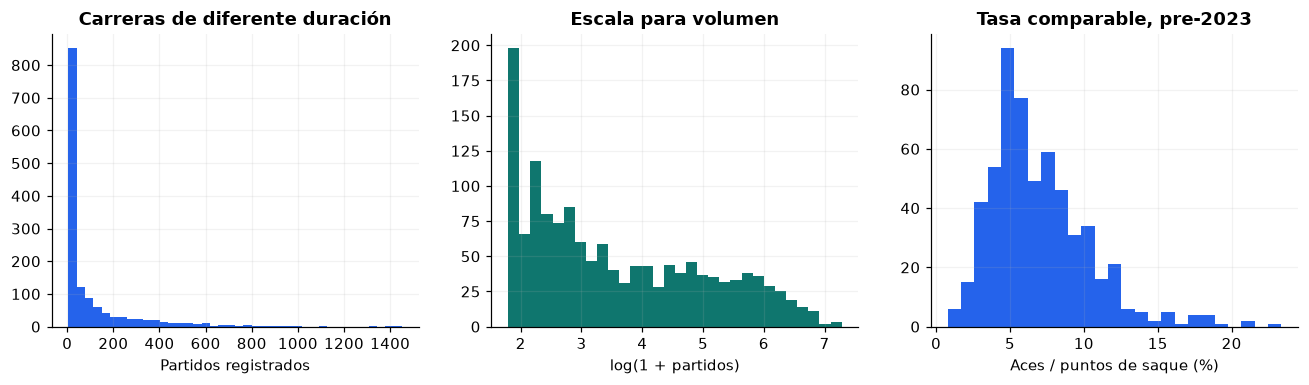

**Asimetría:** partidos = 2.945; log1p(partidos) = 0.573. Se reduce el dominio visual de las carreras largas sin borrar sus observaciones.

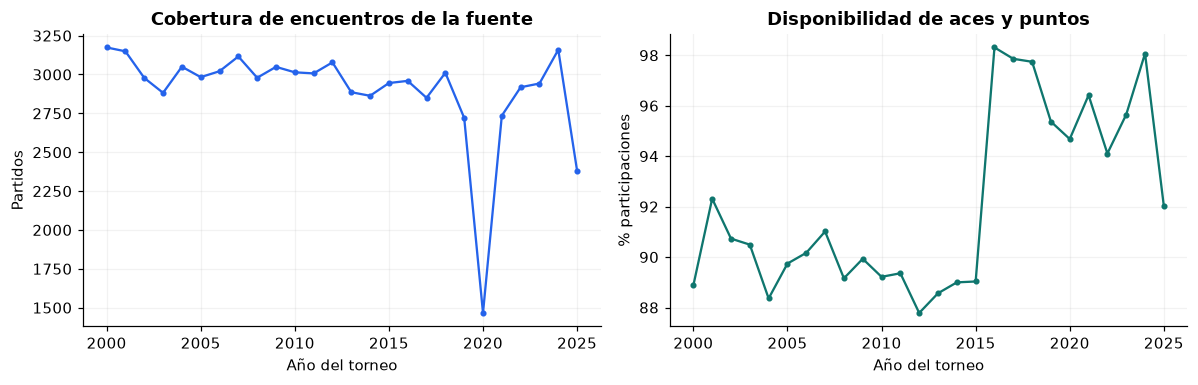

**Decisión temporal:** el Silver agregado no permite ver cómo cambia el estilo de un jugador. Para eso se vuelve a las fechas del consolidado. La fecha es el inicio del torneo, no necesariamente el día exacto del partido. La curva describe archivos disponibles, no popularidad del tenis.

In [4]:
asim = perfil[['columna','asimetria']].dropna().sort_values('asimetria', ascending=False)
exportar(asim, 'asimetria_columnas', False)
display(asim.head(10))
display(df[['partidos-totales','aces-totales','altura-cm']].describe(percentiles=[.5,.9,.99]))
fig, axes = plt.subplots(1, 3, figsize=(12,3.6))
axes[0].hist(df['partidos-totales'], bins=40, color=AZUL)
axes[0].set(title='Carreras de diferente duración', xlabel='Partidos registrados')
axes[1].hist(np.log1p(df['partidos-totales']), bins=30, color=VERDE)
axes[1].set(title='Escala para volumen', xlabel='log(1 + partidos)')
axes[2].hist(dominio.tasa_aces.dropna()*100, bins=25, color=AZUL)
axes[2].set(title='Tasa comparable, pre-2023', xlabel='Aces / puntos de saque (%)')
grafico('02_forma_y_escalas')
texto(f'**Asimetría:** partidos = {df["partidos-totales"].skew():.3f}; '
      f'log1p(partidos) = {np.log1p(df["partidos-totales"]).skew():.3f}. '
      'Se reduce el dominio visual de las carreras largas sin borrar sus observaciones.')
temporal = largo.groupby('anio').agg(participaciones=('partidos','sum'),
    cobertura_aces=('tasa_aces_n','mean')).reset_index()
temporal['partidos'] = temporal.participaciones // 2
exportar(temporal, 'cobertura_por_anio', False)
fig, axes = plt.subplots(1,2,figsize=(11,3.6))
axes[0].plot(temporal.anio, temporal.partidos, marker='.', color=AZUL)
axes[0].set(title='Cobertura de encuentros de la fuente', xlabel='Año del torneo', ylabel='Partidos')
axes[1].plot(temporal.anio, temporal.cobertura_aces*100, marker='.', color=VERDE)
axes[1].set(title='Disponibilidad de aces y puntos', xlabel='Año del torneo', ylabel='% participaciones')
grafico('03_tiempo_y_cobertura')
texto('**Decisión temporal:** el Silver agregado no permite ver cómo cambia el estilo de un jugador. '
      'Para eso se vuelve a las fechas del consolidado. La fecha es el inicio del torneo, '
      'no necesariamente el día exacto del partido. La curva describe archivos disponibles, no popularidad del tenis.')

## 4. Objetivo supervisado real: `gana_a`

La tabla auxiliar conserva una fila por partido. La asignación A/B se decide
con semilla 42, independiente de quién ganó; no se elige A por mayor ranking.
`gana_a` vale 1 si A ganó y 0 si B ganó. El balance cercano a 50% se debe a esa
orientación aleatoria, no a que todos los jugadores tengan igual capacidad.

**Historias sin futuro:** para un partido del año t, las tasas y el winrate
se calculan con temporadas anteriores a t. Se excluye el año completo en
curso; se sacrifica actualidad para evitar ordenar con fechas de partido que
la fuente no proporciona. `max_anio_historial < anio` se comprueba por fila.
Las estadísticas del oponente se cruzan con la misma regla.

El desarrollo supervisado usa años <2023. De 2023–2025 sólo se muestra
cantidad, cobertura y balance. Las hipótesis no seleccionan columnas usando
los resultados de ese período. Como se perfila el Silver completo, es una
reserva temporal de trabajo, no un test externo nunca inspeccionado.

,periodo,gana_a,partidos,proporcion
0,desarrollo,0,21257,0.5039
1,desarrollo,1,20930,0.4961
2,reserva_2023_2025,0,2756,0.5076
3,reserva_2023_2025,1,2673,0.4924


,etapa,partidos
0,Partidos en superficies admitidas,75316
1,Resultado completo (sin marcas W/O/RET/DEF/ABN...,72628
2,Ambos con >=20 partidos de años anteriores,47710
3,Además ambos rankings positivos conocidos,47616
4,Desarrollo (<2023),42187
5,Reserva 2023-2025,5429


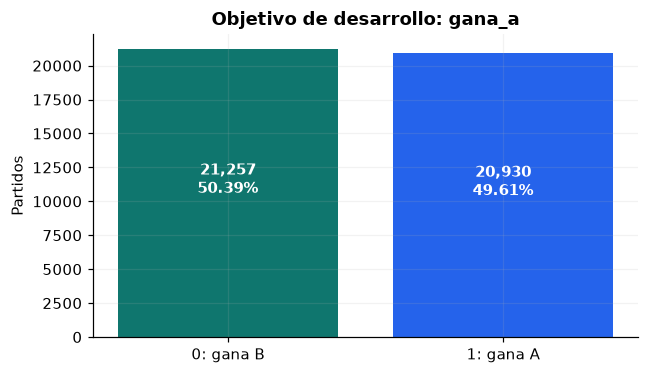

**Clase mayoritaria de desarrollo: 50.39%.** Un clasificador que siempre elija esa clase acertaría 50.39%. La tabla A/B es auxiliar; la clave del Silver sigue siendo id-jugador.

In [5]:
anual = largo.groupby(['id-jugador','anio'])[sumables].sum(min_count=1).reset_index().sort_values(['id-jugador','anio'])
cant = anual[sumables].fillna(0)
previos = cant.groupby(anual['id-jugador']).cumsum() - cant
hist = pd.concat([anual[['id-jugador','anio']].reset_index(drop=True), previos.reset_index(drop=True)],axis=1)
hist = con_tasas(hist)
hist['max_anio_historial'] = anual.groupby('id-jugador')['anio'].shift(1).to_numpy()
HIST_FEATURES = list(RATIOS) + ['winrate','partidos','max_anio_historial']

sin_juego = p.score.fillna('').str.contains(r'W/O|\bWO\b|RET|DEF|ABN', case=False, regex=True)
base_ab = p.loc[~sin_juego & p.score.notna()].sort_values(['fecha','id_partido']).copy()
rng = np.random.default_rng(SEMILLA)
a_ganador = rng.random(len(base_ab)) < .5
ab = base_ab[['id_partido','fecha','anio','surface','tourney_level','best_of']].reset_index(drop=True)
ab['gana_a'] = a_ganador.astype(int)
for suf,cond in [('a',a_ganador),('b',~a_ganador)]:
    for origen,destino in [('id','id'),('rank','ranking'),('ht','altura'),('age','edad')]:
        ab[f'{destino}_{suf}'] = np.where(cond, base_ab[f'winner_{origen}'], base_ab[f'loser_{origen}'])
    ab[f'id_{suf}'] = ab[f'id_{suf}'].astype('string')
    for c in ['ranking','altura','edad']:
        ab[f'{c}_{suf}'] = pd.to_numeric(ab[f'{c}_{suf}'], errors='coerce')
    h = hist[['id-jugador','anio']+HIST_FEATURES].rename(columns={
        'id-jugador':f'id_{suf}', **{c:f'{c}_{suf}' for c in HIST_FEATURES}})
    ab = ab.merge(h, on=[f'id_{suf}','anio'], how='left', validate='many_to_one')
    assert (ab[f'max_anio_historial_{suf}'].dropna() < ab.loc[ab[f'max_anio_historial_{suf}'].notna(),'anio']).all()

for c in list(RATIOS)+['winrate','altura','edad']:
    ab['dif_'+c] = ab[f'{c}_a'] - ab[f'{c}_b']
ab['dif_partidos_log'] = np.log1p(ab.partidos_a) - np.log1p(ab.partidos_b)
rank_ok = ab.ranking_a.gt(0) & ab.ranking_b.gt(0)
ab['dif_ranking'] = (ab.ranking_a - ab.ranking_b).where(rank_ok)
ab['dif_log_ranking'] = (np.log(ab.ranking_a.where(rank_ok))-np.log(ab.ranking_b.where(rank_ok)))
ab['historial_suficiente'] = ab.partidos_a.ge(MIN_PARTIDOS) & ab.partidos_b.ge(MIN_PARTIDOS)
ab['periodo'] = np.where(ab.anio < CORTE, 'desarrollo', 'reserva_2023_2025')
modelo = ab.loc[ab.historial_suficiente & rank_ok].copy()
dev = modelo.loc[modelo.anio < CORTE].copy()
assert modelo.id_partido.is_unique and set(modelo.gana_a.unique()) == {0,1}
balance = modelo.groupby(['periodo','gana_a']).size().rename('partidos').reset_index()
balance['proporcion'] = balance.partidos / balance.groupby('periodo').partidos.transform('sum')
exportar(balance, 'distribucion_objetivo')
exportar(pd.DataFrame([
    {'etapa':'Partidos en superficies admitidas','partidos':len(p)},
    {'etapa':'Resultado completo (sin marcas W/O/RET/DEF/ABN y sin score nulo)','partidos':len(ab)},
    {'etapa':'Ambos con >=20 partidos de años anteriores','partidos':int(ab.historial_suficiente.sum())},
    {'etapa':'Además ambos rankings positivos conocidos','partidos':len(modelo)},
    {'etapa':'Desarrollo (<2023)','partidos':len(dev)},
    {'etapa':'Reserva 2023-2025','partidos':int(modelo.anio.ge(CORTE).sum())},
]), 'trazabilidad_tabla_ab')
fig, ax = plt.subplots(figsize=(6,3.5))
b = dev.gana_a.value_counts().sort_index()
ax.bar(['0: gana B','1: gana A'], b.values, color=[VERDE,AZUL])
for i,v in enumerate(b): ax.text(i,v*.5,f'{v:,}\n{v/len(dev):.2%}',ha='center',color='white',fontweight='bold')
ax.set(title='Objetivo de desarrollo: gana_a', ylabel='Partidos')
grafico('04_objetivo')
texto(f'**Clase mayoritaria de desarrollo: {b.max()/b.sum():.2%}.** '
      f'Un clasificador que siempre elija esa clase acertaría {b.max()/b.sum():.2%}. '
      'La tabla A/B es auxiliar; la clave del Silver sigue siendo id-jugador.')
exportar(modelo, 'partidos_ab_historial_anual', False)
exportar(perfil_pre2023.reset_index(), 'perfiles_jugadores_pre2023', False)

## 5. Cuatro fichas de hipótesis

Se fijaron afirmaciones y expectativas en `PLAN_HIPOTESIS.md` antes de calcular
estas medidas. Las hipótesis de dominio usan perfiles anteriores a 2023, para
no seleccionar patrones con los resultados futuros. Una fila es un jugador en
H1–H3 y un partido auxiliar en H4; cada resultado informa su población.

Los seis campos son los del ejemplo: **afirmación**, **qué espero ver**,
**medida y gráfico**, **resultado y zona**, **movimiento**, **qué hago con eso**.
La zona mide tamaño del efecto, no valor p ni prueba de causalidad.

| Medida | Rojo | Amarillo | Verde |
|---|---|---|---|
| Correlación (valor absoluto) | <0,2 | 0,2–0,6 | >0,6 |
| Separación estandarizada | <0,2 | 0,2–0,8 | >0,8 |
| η² | <0,05 | 0,05–0,25 | >0,25 |
| Brecha Pearson/Spearman | <0,05 | 0,05–0,15 | >0,15 |

Se usa la medida sin redondear para decidir la zona. El signo se informa aparte.
Rojo o verde termina la ficha. Amarillo permite hasta dos movimientos,
justificados por el gráfico; no obliga a agotar los dos.

In [6]:
CORTES = {'correlacion':(.2,.6),'separacion':(.2,.8),'eta2':(.05,.25),'brecha':(.05,.15)}
# Asigna la zona del semáforo según los cortes fijados.
def zona(v, m):
    if pd.isna(v): return 'no estimable'
    a,b = CORTES[m]
    return 'rojo' if abs(v)<a else 'verde' if abs(v)>b else 'amarillo'
# Calcula Pearson, Spearman y su brecha.
def asociacion(x,y):
    v=pd.concat([x,y],axis=1).dropna()
    pear=v.iloc[:,0].corr(v.iloc[:,1])
    spe=v.iloc[:,0].rank().corr(v.iloc[:,1].rank())
    return {'n':len(v),'pearson':pear,'spearman':spe,'brecha':spe-pear}
# Compara dos grupos en desviaciones estándar.
def separacion(x,y):
    x,y=x.dropna(),y.dropna()
    den=np.sqrt((x.std()**2+y.std()**2)/2)
    return abs(x.mean()-y.mean())/den if den>0 else np.nan
# Calcula la proporción de varianza explicada por los grupos.
def eta2(x,c):
    v=pd.DataFrame({'x':x,'c':c}).dropna()
    g=v.groupby('c').x
    total=((v.x-v.x.mean())**2).sum()
    return (g.count()*(g.mean()-v.x.mean())**2).sum()/total if total>0 else np.nan
fichas=[]
# Registra y presenta los seis campos de una hipótesis.
def ficha(id, tipo, afirmacion, expectativa, medida, resultado, movimiento, decision, valor, metrica, estado, n):
    row=dict(id=id,tipo=tipo,afirmacion=afirmacion,expectativa=expectativa,medida=medida,
             resultado=resultado,movimiento=movimiento,decision=decision,valor=float(valor),
             zona=zona(valor,metrica),estado=estado,n=int(n))
    fichas.append(row)
    texto('\n\n'.join([f'### {id} · {tipo}',f'**1. Afirmación.** {afirmacion}',
        f'**2. Qué espero ver.** {expectativa}',f'**3. Medida y gráfico.** {medida}',
        f'**4. Resultado y zona.** {resultado}',f'**5. Movimiento.** {movimiento}',
        f'**6. Qué hago con eso.** {decision}']))

### H1 · Altura y tasa de aces
**Antes de calcular:** espero asociación positiva fuerte (Pearson >0,6).
La altura se toma de la última medición registrada en los partidos pre-2023.
Casos con >=20 participaciones, >=500 puntos y cobertura de aces >=80%.

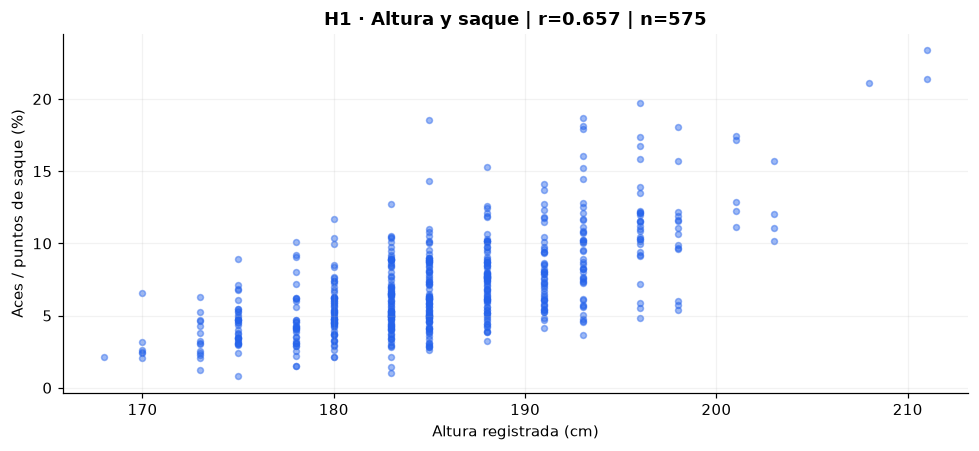

### H1 · Dominio

**1. Afirmación.** Los jugadores más altos presentan una tasa de aces fuertemente mayor.

**2. Qué espero ver.** Nube ascendente y Pearson >0,6; el total de aces no se usa porque mezcla estilo y duración de carrera.

**3. Medida y gráfico.** Asociación: Pearson principal, Spearman y brecha complementarios. Dispersión H1_altura_aces.png.

**4. Resultado y zona.** n=575; Pearson=0.6569 (verde); Spearman=0.6202; brecha=-0.0367 (rojo). CONFIRMADA respecto de una asociación fuerte.

**5. Movimiento.** 0 movimientos. Se conserva la población prefijada; si es amarillo queda abierto sin buscar recortes que eleven r.

**6. Qué hago con eso.** Altura y tasa de aces se describen conjuntamente. La tasa entra como rasgo técnico candidato; altura como contexto. La asociación no demuestra que la altura cause aces ni que prediga por sí sola al ganador.

In [7]:
h1m=dominio.dropna(subset=['altura','tasa_aces'])
h1=asociacion(h1m.altura,h1m.tasa_aces)
fig,ax=plt.subplots()
ax.scatter(h1m.altura,h1m.tasa_aces*100,s=15,alpha=.45,color=AZUL)
ax.set(xlabel='Altura registrada (cm)',ylabel='Aces / puntos de saque (%)',
       title=f"H1 · Altura y saque | r={h1['pearson']:.3f} | n={h1['n']}")
grafico('H1_altura_aces')
z1=zona(h1['pearson'],'correlacion')
estado1='confirmada' if z1=='verde' and h1['pearson']>0 else 'refutada' if z1=='rojo' or h1['pearson']<0 else 'inconclusa'
ficha('H1','Dominio','Los jugadores más altos presentan una tasa de aces fuertemente mayor.',
    'Nube ascendente y Pearson >0,6; el total de aces no se usa porque mezcla estilo y duración de carrera.',
    'Asociación: Pearson principal, Spearman y brecha complementarios. Dispersión H1_altura_aces.png.',
    f"n={h1['n']}; Pearson={h1['pearson']:.4f} ({z1}); Spearman={h1['spearman']:.4f}; brecha={h1['brecha']:.4f} ({zona(h1['brecha'],'brecha')}). {estado1.upper()} respecto de una asociación fuerte.",
    '0 movimientos. Se conserva la población prefijada; si es amarillo queda abierto sin buscar recortes que eleven r.',
    'Altura y tasa de aces se describen conjuntamente. La tasa entra como rasgo técnico candidato; altura como contexto. '
    'La asociación no demuestra que la altura cause aces ni que prediga por sí sola al ganador.',
    h1['pearson'],'correlacion',estado1,h1['n'])

### H2 · ¿Los zurdos ganan mucho más?
**Antes de calcular:** espero media superior en zurdos y separación >0,8.
Se consideran todos los jugadores pre-2023 con >=20 resultados y mano R/L
conocida; no hace falta cobertura de saque para contar victorias.

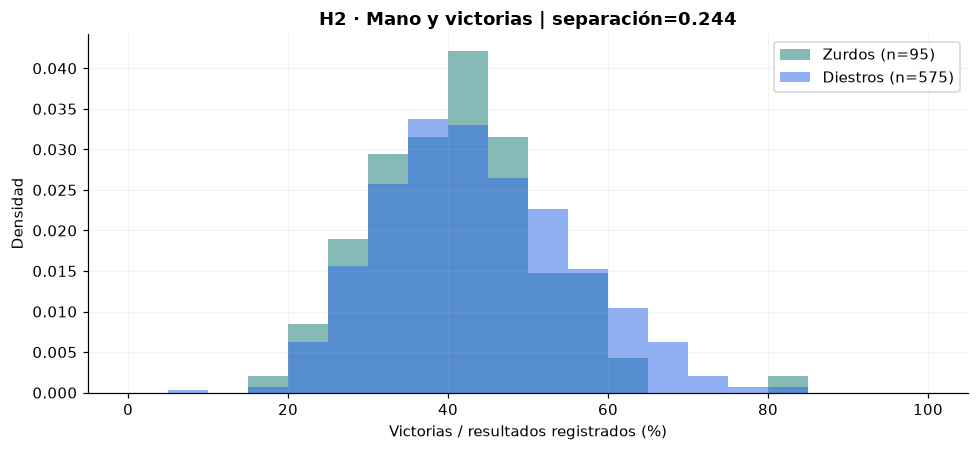

### H2 · Dominio

**1. Afirmación.** Los zurdos tienen una ventaja grande en porcentaje de victorias frente a los diestros.

**2. Qué espero ver.** Media de zurdos mayor y separación estandarizada >0,8.

**3. Medida y gráfico.** Separación = |media L - media R| / raíz((var L + var R)/2). Histogramas comunes, H2_mano_victorias.png.

**4. Resultado y zona.** L: n=95, media=40.83%; R: n=575, media=43.56%; diferencia L-R=-2.736 puntos porcentuales; separación=0.2436 (amarillo). INCONCLUSA. El signo observado se informa aparte: no se considera confirmada una ventaja de zurdos con diferencia negativa.

**5. Movimiento.** 0 movimientos. Las distribuciones se muestran sobre los mismos intervalos; no se busca una superficie donde cambie el resultado.

**6. Qué hago con eso.** No presentar ser zurdo como ventaja grande demostrada si el resultado es rojo/amarillo. La mano puede conservarse para describir perfiles, pero su valor predictivo condicional requerirá validación; no se confunde efecto pequeño con prueba de igualdad exacta.

In [8]:
h2m=perfil_pre2023.loc[perfil_pre2023.partidos.ge(MIN_PARTIDOS) & perfil_pre2023.mano.isin(['L','R'])]
zur=h2m.loc[h2m.mano.eq('L'),'winrate']
die=h2m.loc[h2m.mano.eq('R'),'winrate']
sep=separacion(zur,die)
delta=zur.mean()-die.mean()
fig,ax=plt.subplots()
for s,label,col in [(zur,'Zurdos',VERDE),(die,'Diestros',AZUL)]:
    ax.hist(s*100,bins=np.linspace(0,100,21),density=True,alpha=.5,label=f'{label} (n={len(s)})',color=col)
ax.set(xlabel='Victorias / resultados registrados (%)',ylabel='Densidad',title=f'H2 · Mano y victorias | separación={sep:.3f}')
ax.legend()
grafico('H2_mano_victorias')
z2=zona(sep,'separacion')
estado2='inconclusa' if z2=='amarillo' else 'refutada' if z2=='rojo' or delta<0 else 'confirmada'
ficha('H2','Dominio','Los zurdos tienen una ventaja grande en porcentaje de victorias frente a los diestros.',
    'Media de zurdos mayor y separación estandarizada >0,8.',
    'Separación = |media L - media R| / raíz((var L + var R)/2). Histogramas comunes, H2_mano_victorias.png.',
    f'L: n={len(zur)}, media={zur.mean():.2%}; R: n={len(die)}, media={die.mean():.2%}; '
    f'diferencia L-R={100*delta:.3f} puntos porcentuales; separación={sep:.4f} ({z2}). {estado2.upper()}. '
    'El signo observado se informa aparte: no se considera confirmada una ventaja de zurdos con diferencia negativa.',
    '0 movimientos. Las distribuciones se muestran sobre los mismos intervalos; no se busca una superficie donde cambie el resultado.',
    'No presentar ser zurdo como ventaja grande demostrada si el resultado es rojo/amarillo. '
    'La mano puede conservarse para describir perfiles, pero su valor predictivo condicional requerirá validación; '
    'no se confunde efecto pequeño con prueba de igualdad exacta.',sep,'separacion',estado2,len(h2m))

### H3 · ¿El total de aces mide estilo o exposición?
**Antes de calcular:** espero Pearson >0,6 entre cantidad de partidos y
aces acumulados. Uso la población de H1 sin exigir altura. Esta hipótesis
decide si conviene entregar al clustering conteos crudos o tasas.

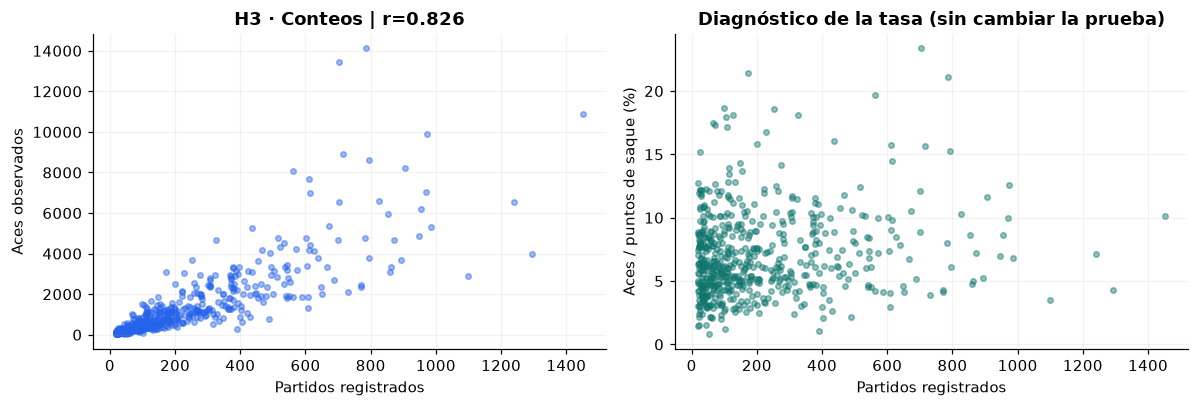

### H3 · Columnas del clustering

**1. Afirmación.** El total de aces se asocia fuertemente con el volumen de partidos.

**2. Qué espero ver.** Nube ascendente y Pearson >0,6: las carreras más extensas ofrecen más oportunidades de acumular aces.

**3. Medida y gráfico.** Pearson y Spearman; dispersión partidos/aces, con gráfico diagnóstico partidos/tasa. H3_exposicion.png.

**4. Resultado y zona.** n=575; Pearson=0.8257 (verde); Spearman=0.9203; brecha=0.0946 (amarillo). CONFIRMADA.

**5. Movimiento.** 0 movimientos. El segundo panel ilustra la normalización propuesta, no reemplaza la medida prefijada.

**6. Qué hago con eso.** Excluir aces-totales y demás conteos de carrera del clustering inicial; usar tasas con cobertura. Conservar log1p(partidos) solo como control de experiencia para predicción. Correlación alta no demuestra que dos columnas sean intercambiables ni que la tasa sea independiente de la experiencia.

In [9]:
h3=asociacion(dominio.partidos,dominio.tasa_aces_num)
fig,axes=plt.subplots(1,2,figsize=(11,3.8))
axes[0].scatter(dominio.partidos,dominio.tasa_aces_num,s=13,alpha=.45,color=AZUL)
axes[0].set(xlabel='Partidos registrados',ylabel='Aces observados',title=f"H3 · Conteos | r={h3['pearson']:.3f}")
axes[1].scatter(dominio.partidos,dominio.tasa_aces*100,s=13,alpha=.45,color=VERDE)
axes[1].set(xlabel='Partidos registrados',ylabel='Aces / puntos de saque (%)',title='Diagnóstico de la tasa (sin cambiar la prueba)')
grafico('H3_exposicion')
z3=zona(h3['pearson'],'correlacion')
estado3='confirmada' if z3=='verde' and h3['pearson']>0 else 'refutada' if z3=='rojo' or h3['pearson']<0 else 'inconclusa'
ficha('H3','Columnas del clustering','El total de aces se asocia fuertemente con el volumen de partidos.',
    'Nube ascendente y Pearson >0,6: las carreras más extensas ofrecen más oportunidades de acumular aces.',
    'Pearson y Spearman; dispersión partidos/aces, con gráfico diagnóstico partidos/tasa. H3_exposicion.png.',
    f"n={h3['n']}; Pearson={h3['pearson']:.4f} ({z3}); Spearman={h3['spearman']:.4f}; "
    f"brecha={h3['brecha']:.4f} ({zona(h3['brecha'],'brecha')}). {estado3.upper()}.",
    '0 movimientos. El segundo panel ilustra la normalización propuesta, no reemplaza la medida prefijada.',
    'Excluir aces-totales y demás conteos de carrera del clustering inicial; usar tasas con cobertura. '
    'Conservar log1p(partidos) solo como control de experiencia para predicción. '
    'Correlación alta no demuestra que dos columnas sean intercambiables ni que la tasa sea independiente de la experiencia.',
    h3['pearson'],'correlacion',estado3,h3['n'])

### H4 · Ranking y ganador: decisión sobre una columna predictiva
**Antes de calcular:** espero η² >0,25 entre `dif_ranking` y las clases de
`gana_a`. Diferencia = ranking A − ranking B: negativo favorece a A, porque
un número de ranking menor representa mejor posición.
Población: desarrollo (<2023), ambos con historial previo >=20 y ranking conocido.

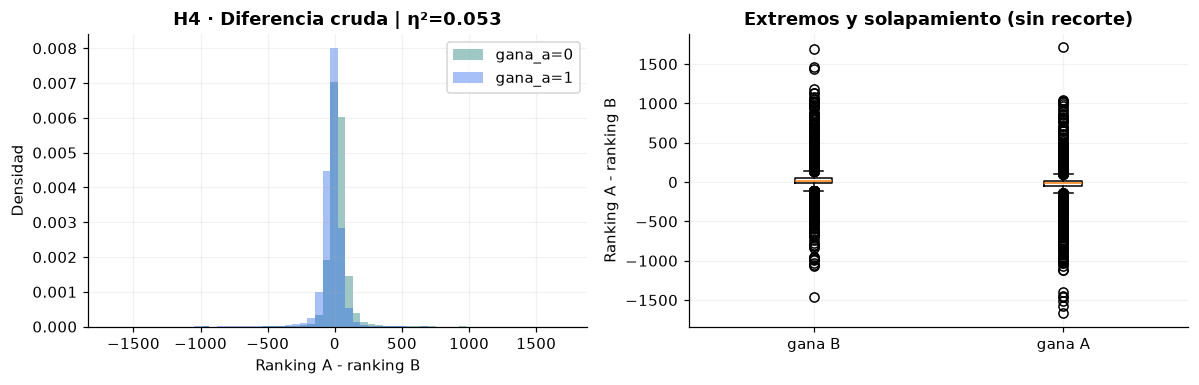

**Primera medida: η²=0.0535, zona amarillo.** Asimetría del ranking individual A: 6.723. Las colas/extremos comprimen las diferencias cercanas al centro: el gráfico se usa para decidir si cambiar escala.

In [10]:
e4=eta2(dev.dif_ranking,dev.gana_a)
fig,axes=plt.subplots(1,2,figsize=(11,3.6))
for y,c in [(0,VERDE),(1,AZUL)]:
    v=dev.loc[dev.gana_a.eq(y),'dif_ranking']
    axes[0].hist(v,bins=np.linspace(dev.dif_ranking.min(),dev.dif_ranking.max(),61),density=True,alpha=.4,color=c,label=f'gana_a={y}')
axes[0].set(xlabel='Ranking A - ranking B',ylabel='Densidad',title=f'H4 · Diferencia cruda | η²={e4:.3f}')
axes[0].legend()
axes[1].boxplot([dev.loc[dev.gana_a.eq(y),'dif_ranking'] for y in [0,1]],tick_labels=['gana B','gana A'])
axes[1].set(ylabel='Ranking A - ranking B',title='Extremos y solapamiento (sin recorte)')
grafico('H4_ranking_crudo')
texto(f'**Primera medida: η²={e4:.4f}, zona {zona(e4,"eta2")}.** '
      f'Asimetría del ranking individual A: {dev.ranking_a.skew():.3f}. '
      'Las colas/extremos comprimen las diferencias cercanas al centro: el gráfico se usa para decidir si cambiar escala.')

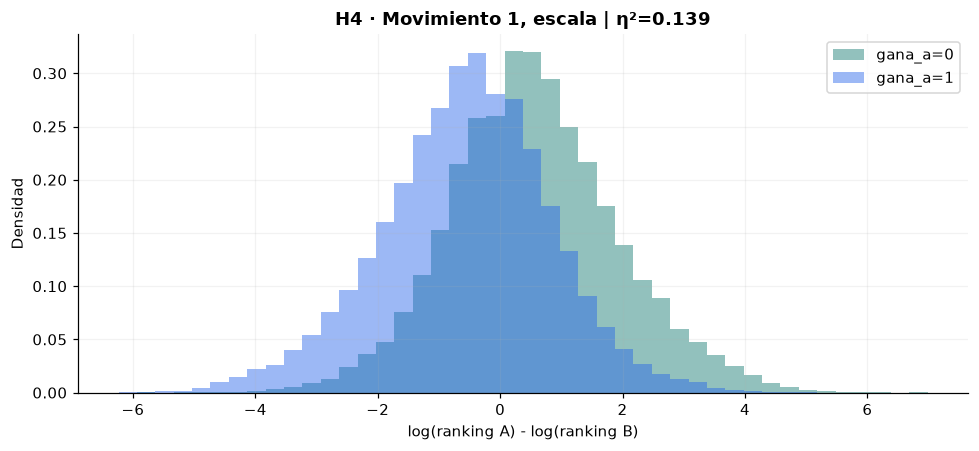

### H4 · Columnas de predicción

**1. Afirmación.** La diferencia de ranking separa fuertemente a las clases de gana_a.

**2. Qué espero ver.** η² >0,25 y distribuciones claramente separadas. No basta con una diferencia visible de medias.

**3. Medida y gráfico.** η²: varianza entre clases / varianza total de la columna. Histogramas y boxplot H4_ranking_crudo.png.

**4. Resultado y zona.** n=42187; η² inicial=0.0535 (amarillo); η² final=0.1391 (amarillo). INCONCLUSA respecto de una separación fuerte.

**5. Movimiento.** 1 movimiento: diferencia de log-rankings, motivado por las colas que comprimen el centro en el gráfico inicial. Si sigue amarillo se detiene: no hay evidencia gráfica que justifique buscar un subgrupo favorable.

**6. Qué hago con eso.** Conservar diferencia logarítmica de ranking como candidato y referencia del modelo base; amarillo significa señal parcial, no inutilidad. No prometer que los estilos superan al ranking: eso se medirá en Entrega 3. η² no es accuracy ni proporción de ganadores explicados.

,id,tipo,n,valor,zona,estado
0,H1,Dominio,575,0.6569,verde,confirmada
1,H2,Dominio,670,0.2436,amarillo,inconclusa
2,H3,Columnas del clustering,575,0.8257,verde,confirmada
3,H4,Columnas de predicción,42187,0.1391,amarillo,inconclusa


In [11]:
mov4 = zona(e4,'eta2') == 'amarillo'
e4final = eta2(dev.dif_log_ranking,dev.gana_a) if mov4 else e4
variable4 = 'dif_log_ranking' if mov4 else 'dif_ranking'
if mov4:
    fig,ax=plt.subplots()
    bins=np.linspace(dev.dif_log_ranking.min(),dev.dif_log_ranking.max(),45)
    for y,c in [(0,VERDE),(1,AZUL)]:
        ax.hist(dev.loc[dev.gana_a.eq(y),'dif_log_ranking'],bins=bins,density=True,alpha=.45,color=c,label=f'gana_a={y}')
    ax.set(xlabel='log(ranking A) - log(ranking B)',ylabel='Densidad',title=f'H4 · Movimiento 1, escala | η²={e4final:.3f}')
    ax.legend()
    grafico('H4_movimiento_log')
z4=zona(e4final,'eta2')
estado4='confirmada' if z4=='verde' else 'refutada' if z4=='rojo' else 'inconclusa'
ficha('H4','Columnas de predicción','La diferencia de ranking separa fuertemente a las clases de gana_a.',
    'η² >0,25 y distribuciones claramente separadas. No basta con una diferencia visible de medias.',
    'η²: varianza entre clases / varianza total de la columna. Histogramas y boxplot H4_ranking_crudo.png.',
    f'n={len(dev)}; η² inicial={e4:.4f} ({zona(e4,"eta2")}); '
    f'η² final={e4final:.4f} ({z4}). {estado4.upper()} respecto de una separación fuerte.',
    ('1 movimiento: diferencia de log-rankings, motivado por las colas que comprimen el centro en el gráfico inicial. '
     'Si sigue amarillo se detiene: no hay evidencia gráfica que justifique buscar un subgrupo favorable.' if mov4 else
     '0 movimientos: el semáforo inicial termina la prueba. No se transforma para intentar cambiar la zona.'),
    'Conservar diferencia logarítmica de ranking como candidato y referencia del modelo base; '
    'amarillo significa señal parcial, no inutilidad. No prometer que los estilos superan al ranking: '
    'eso se medirá en Entrega 3. η² no es accuracy ni proporción de ganadores explicados.',
    e4final,'eta2',estado4,len(dev))
resumen_fichas=pd.DataFrame(fichas)
exportar(resumen_fichas,'fichas_hipotesis',False)
def color_zona(v):
    colores={'verde':'#dcfce7','amarillo':'#fef3c7','rojo':'#fee2e2'}
    return 'background-color: '+colores.get(v,'#f1f5f9')+'; color: #111827;'
display(resumen_fichas[['id','tipo','n','valor','zona','estado']].style.format({'valor':'{:.4f}'}).map(color_zona,subset=['zona']))
assert len(fichas)==4 and any(f['estado'] in ['refutada','inconclusa'] for f in fichas)

## 6. Sensibilidad y relaciones complementarias

El mínimo de partidos y la cobertura afectan qué jugadores se estudian.
Se muestran todas las combinaciones declaradas, sin reemplazar la ficha por
la que dé mejor número. Es un diagnóstico de robustez, no un nuevo movimiento
para “confirmar” H1. La incertidumbre con pocos partidos no desaparece por
imputar una tasa. Estas medidas describen la fuente; encuentros repetidos y
carreras con distinta duración impiden tratarlos como observaciones independientes
para afirmaciones causales o pruebas ingenuas de significación.

,min_partidos,min_cobertura,n_completos,pearson_altura_aces,zona
0,5,0.5000,788,0.6211,verde
1,5,0.8000,720,0.6379,verde
2,5,0.9500,483,0.6508,verde
3,20,0.5000,612,0.6477,verde
4,20,0.8000,575,0.6569,verde
5,20,0.9500,375,0.6723,verde
6,50,0.5000,464,0.6577,verde
7,50,0.8000,446,0.6656,verde
8,50,0.9500,289,0.6907,verde


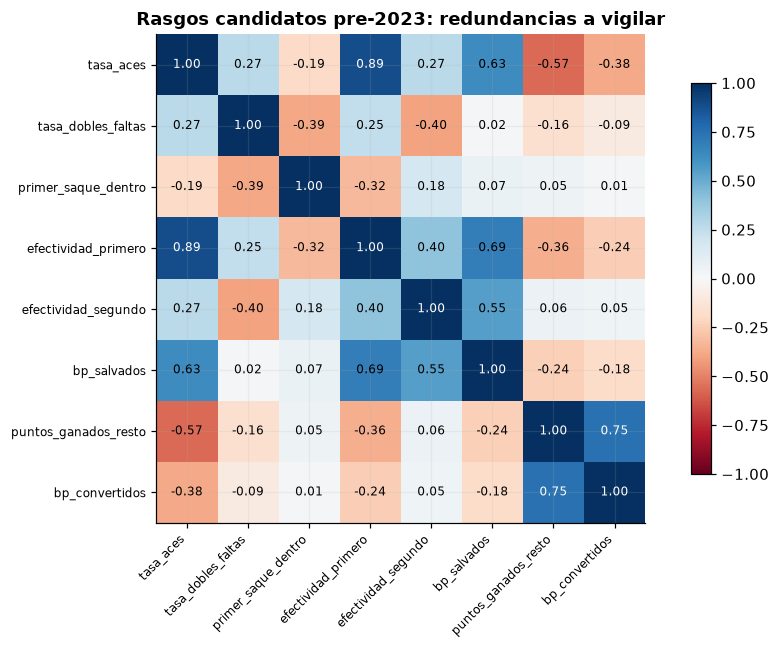

**Decisión:** revisar redundancias antes de ponderar rasgos. Una correlación alta entre dos rasgos no prueba que sean equivalentes; se compararán modelos y estabilidad del clustering. No se usa winrate o títulos para construir estilos si luego se quiere comparar cuál estilo gana más: eso incorporaría el criterio de superioridad dentro de la definición del grupo.

In [12]:
sens=[]
for minimo in [5,20,50]:
    for cobertura in [.5,.8,.95]:
        v=perfil_pre2023.loc[perfil_pre2023.partidos.ge(minimo) & perfil_pre2023.tasa_aces_den.ge(500) & perfil_pre2023.cobertura_tasa_aces.ge(cobertura)]
        a=asociacion(v.altura,v.tasa_aces)
        sens.append({'min_partidos':minimo,'min_cobertura':cobertura,'n_completos':a['n'],
                     'pearson_altura_aces':a['pearson'],'zona':zona(a['pearson'],'correlacion')})
exportar(pd.DataFrame(sens),'sensibilidad_filtros')
corr=dominio[list(RATIOS)].corr()
fig,ax=plt.subplots(figsize=(9,6))
im=ax.imshow(corr,vmin=-1,vmax=1,cmap='RdBu')
ax.set_xticks(range(len(corr)),corr.columns,rotation=45,ha='right',fontsize=8)
ax.set_yticks(range(len(corr)),corr.columns,fontsize=8)
for i in range(len(corr)):
    for k in range(len(corr)): ax.text(k,i,f'{corr.iloc[i,k]:.2f}',ha='center',va='center',fontsize=8,
                                      color='white' if abs(corr.iloc[i,k])>.7 else 'black')
ax.set_title('Rasgos candidatos pre-2023: redundancias a vigilar')
fig.colorbar(im,ax=ax,shrink=.8)
grafico('05_correlacion_rasgos')
texto('**Decisión:** revisar redundancias antes de ponderar rasgos. Una correlación alta entre '
      'dos rasgos no prueba que sean equivalentes; se compararán modelos y estabilidad del clustering. '
      'No se usa winrate o títulos para construir estilos si luego se quiere comparar cuál estilo gana más: '
      'eso incorporaría el criterio de superioridad dentro de la definición del grupo.')

## 7. Tabla de columnas candidatas y control de fuga

Se separan **rasgos del clustering** de **features del ganador**. La columna
`zona` de los rasgos se refiere a la evidencia indicada, no a “predice el cluster”:
no hay clusters observados todavía. Para las features numéricas A/B, se calcula
η² contra `gana_a` **solo en desarrollo**. Una zona roja univariada no descarta
una interacción; por eso algunas quedan para una comparación posterior.
`No aplica` es explícito para IDs y `pendiente` para etiquetas aún no aprendidas.

**Regla de disponibilidad:** una tasa acumulada a 2025 no existía en un partido
de 2010. La versión predictiva debe provenir exclusivamente del historial
anterior. Las medias, imputaciones, escalas y clusters se ajustarán en
entrenamiento; se transformará la reserva con esos mismos ajustes.

In [13]:
candidatas=[]
# Agrega una decisión a la tabla de columnas candidatas.
def candidata(col,mide,z,decision,existe,uso,evidencia):
    candidatas.append({'columna':col,'que_mide':mide,'zona':z,'decision':decision,
                      'existiria_al_predecir':existe,'uso':uso,'evidencia':evidencia})
for c in RATIOS:
    candidata(c,SIGNIFICADOS[c],'pendiente',
        'Entra como candidato; estandarizar y controlar cobertura.',
        'Sí, recalculada con temporadas anteriores; no el acumulado futuro.',
        'Clustering de estilos','No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada.')
candidata('altura','Altura en cm del último registro previo',z1,
    'Contexto y variante de clustering; imputar con entrenamiento si hace falta.',
    'Sí, si se usa registro histórico. Biografía actual requiere cautela.', 'Clustering',f'H1: r={h1["pearson"]:.4f}')
candidata('mano','Mano R/L',z2,'Describir; no asumir ventaja grande. Codificar categoría para probar interacciones.',
    'Sí, registro histórico.', 'Clustering / contexto',f'H2: separación={sep:.4f}')
for c in ['winrate','titulos','partidos']:
    candidata(c,'Éxito o exposición acumulados','no aplica','Sale del clustering; evaluación externa o control de experiencia.',
        'Solo pasado; el acumulado completo no.', 'Evaluación de estilos','Evitar definir grupos por éxito y luego afirmar que unos son más exitosos.')

NUMERICAS=['dif_ranking','dif_log_ranking','dif_altura','dif_edad','dif_partidos_log','dif_winrate']+['dif_'+c for c in RATIOS]
for c in NUMERICAS:
    e=eta2(dev[c],dev.gana_a)
    z=zona(e,'eta2')
    if c=='dif_ranking': decision='Sale de la especificación inicial; se prefiere log-rank. Evitar las dos diferencias juntas.'
    elif c=='dif_log_ranking': decision='Entra al modelo base y ampliado como referencia; señal parcial no equivale a inutilidad.'
    elif c=='dif_winrate': decision='Candidato de control de fuerza; comparar con/sin él en validación temporal.'
    elif c in ['dif_altura','dif_edad']: decision='No entra al núcleo inicial; candidato débil para contrastar en validación.'
    else: decision='Candidato al ampliado; no prometer utilidad incremental por una medida univariada.'
    candidata(c,'Diferencia A-B de '+c.removeprefix('dif_'),z,decision,
        'Sí: ranking/atributos pretorneo; tasas y experiencia solo de años anteriores.',
        'Ganador A/B',f'η² desarrollo={e:.6f}; casos completos={dev[c].notna().sum()}; nulos={dev[c].isna().mean():.2%}')
for c in ['surface','tourney_level','best_of']:
    candidata(c,'Contexto conocido del encuentro','pendiente','Entra como contexto; mismo contexto en base y ampliado para aislar aporte de estilos.',
        'Sí, antes del encuentro.','Ganador A/B','No se fuerza η² con dos categóricas; probar interacciones en Entrega 3.')
for c in ['estilo_a','estilo_b','interaccion_estilos']:
    candidata(c,'Cluster de A/B o combinación de ambos','pendiente','Construir en Entrega 3 y evaluar contra base con igual contexto.',
        'Sí, solo si clusters y perfiles se estiman con datos anteriores.','Ganador A/B','Aún no existe; no se inventan grupos ni semáforos.')
for c,m in [('id_partido','Clave'),('id_a','Identificación de A'),('id_b','Identificación de B'),('fecha','Corte temporal')]:
    candidata(c,m,'no aplica','Metadato, no feature numérica.', 'Sí.','Trazabilidad','IDs no miden habilidad; fecha organiza validación.')
for c in ['score','minutes','winner_id','loser_id','w_ace','l_ace','victorias-totales','titulos-grand-slam-cemento']:
    candidata(c,'Resultado o estadística posterior / acumulado de carrera','no aplica',
        'Sale por fuga para predecir ese mismo partido.',
        'No: se define durante/después del encuentro o acumula temporadas posteriores.',
        'Control de fuga','Su uso retrospectivo es legítimo; como predictor histórico revela futuro.')
candidata('gana_a','Resultado: 1 ganó A; 0 ganó B','no aplica','Objetivo; jamás entra a X.',
    'No, se observa al terminar.','Objetivo',f'Distribución en distribucion_objetivo.csv; desarrollo n={len(dev)}')
tabla_candidatas=pd.DataFrame(candidatas)
exportar(tabla_candidatas,'columnas_candidatas',False)
display(tabla_candidatas.style.map(color_zona,subset=['zona']).set_properties(**{
    'white-space':'normal','text-align':'left','max-width':'310px','font-size':'12px'}))

decisiones=[]
for c in df.columns:
    if c in constantes: d='Sale: constante en este snapshot'; e='No aporta variación'; z='no aplica'
    elif c in ['id-jugador','nombre-jugador','pais','fecha-nacimiento','año-profesional']:
        d='Referencia; no entra al núcleo de estilo'; e='Identificación/contexto; fecha de nacimiento no es edad del partido'; z='no aplica'
    elif c in ['altura-cm','peso-kg','mano-dominante','tipo-reves']:
        d='Describir; considerar versión histórica y faltantes antes de usar'; e='El snapshot biográfico no garantiza disponibilidad histórica'; z='pendiente'
    else:
        d='No entra como total crudo; insumo de tasas o evaluación externa'
        e='Acumulado al final del período: no estaba disponible para partidos anteriores'; z=z3 if c.startswith('aces-') else 'no aplica'
    decisiones.append({'columna':c,'zona':z,'decision':d,'motivo_disponibilidad':e})
exportar(pd.DataFrame(decisiones),'decisiones_89_columnas_silver',False)

,columna,que_mide,zona,decision,existiria_al_predecir,uso,evidencia
0,tasa_aces,Aces / puntos de saque: frecuencia de puntos ganados directamente con el servicio.,pendiente,Entra como candidato; estandarizar y controlar cobertura.,"Sí, recalculada con temporadas anteriores; no el acumulado futuro.",Clustering de estilos,"No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada."
1,tasa_dobles_faltas,Dobles faltas / puntos de saque: frecuencia de errores de ambos servicios.,pendiente,Entra como candidato; estandarizar y controlar cobertura.,"Sí, recalculada con temporadas anteriores; no el acumulado futuro.",Clustering de estilos,"No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada."
2,primer_saque_dentro,Primeros saques dentro / puntos de saque: regularidad del primer servicio.,pendiente,Entra como candidato; estandarizar y controlar cobertura.,"Sí, recalculada con temporadas anteriores; no el acumulado futuro.",Clustering de estilos,"No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada."
3,efectividad_primero,Puntos ganados con primer saque / primeros saques dentro: éxito cuando entra.,pendiente,Entra como candidato; estandarizar y controlar cobertura.,"Sí, recalculada con temporadas anteriores; no el acumulado futuro.",Clustering de estilos,"No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada."
4,efectividad_segundo,Puntos ganados con segundo saque / (puntos de saque - primeros dentro). Incluye dobles faltas entre intentos.,pendiente,Entra como candidato; estandarizar y controlar cobertura.,"Sí, recalculada con temporadas anteriores; no el acumulado futuro.",Clustering de estilos,"No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada."
5,bp_salvados,Break points salvados / enfrentados: proporción de oportunidades de quiebre evitadas al sacar.,pendiente,Entra como candidato; estandarizar y controlar cobertura.,"Sí, recalculada con temporadas anteriores; no el acumulado futuro.",Clustering de estilos,"No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada."
6,puntos_ganados_resto,(Puntos de saque del rival - primeros y segundos ganados por el rival) / puntos de saque del rival.,pendiente,Entra como candidato; estandarizar y controlar cobertura.,"Sí, recalculada con temporadas anteriores; no el acumulado futuro.",Clustering de estilos,"No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada."
7,bp_convertidos,(Break points enfrentados por el rival - salvados por el rival) / enfrentados por el rival: oportunidades convertidas.,pendiente,Entra como candidato; estandarizar y controlar cobertura.,"Sí, recalculada con temporadas anteriores; no el acumulado futuro.",Clustering de estilos,"No hay etiqueta verdadera; EDA de dispersión/correlación, no eficacia predictiva demostrada."
8,altura,Altura en cm del último registro previo,verde,Contexto y variante de clustering; imputar con entrenamiento si hace falta.,"Sí, si se usa registro histórico. Biografía actual requiere cautela.",Clustering,H1: r=0.6569
9,mano,Mano R/L,amarillo,Describir; no asumir ventaja grande. Codificar categoría para probar interacciones.,"Sí, registro histórico.",Clustering / contexto,H2: separación=0.2436


## 8. Decisiones para la Entrega 3 y límites de las conclusiones

1. **Silver:** se conserva la tabla de jugadores y su clave; la tabla A/B es
   auxiliar para la tercera pregunta, no una reversión de la corrección docente.
2. **Calidad:** distinguir nulos reales, ceros estructurales y sumas de datos
   desconocidos. Guardar cobertura por tasa; no completar con cero porcentajes
   sin oportunidades. El notebook corrige las tasas derivadas sin alterar los originales.
3. **Clustering:** tasas de saque y resto; escala ajustada en entrenamiento.
   Comparar estilos por éxito requiere dejar victorias/títulos fuera de la
   construcción de clusters. Los nombres se asignarán después de interpretar centroides.
4. **Predicción:** ranking y contexto como base; mismo contexto + estilos como
   ampliado. Se compararán en los mismos encuentros, con una métrica prefijada
   (por ejemplo log loss, además de ROC AUC). Para atribuir mejora a estilos
   no se debe añadir superficie únicamente al modelo ampliado.
5. **Temporalidad:** perfiles congelados por año. En Entrega 3 conviene validación
   temporal dentro de desarrollo y una evaluación final en reserva, sin ajustar
   decisiones tras verla. El año previo pierde forma reciente; es una limitación explícita.
6. **Alcance de la muestra:** filtros pueden dejar menos de 1.000 jugadores para
   una hipótesis. El Silver tiene 1.414; no se afirma que el subconjunto analítico
   satisfaga ese volumen. No se agregan jugadores artificiales para cumplirlo.
7. **Interpretación:** asociación no es causalidad. La habilidad de rivales,
   superficie, época y duración de carrera pueden explicar diferencias. No se
   declara un estilo “defensivo” solo por tener pocos aces o muchos BP salvados.

### Lo que queda inconcluso y qué hace falta
Las fichas amarillas no se fuerzan a verde. Se necesita validación temporal
multivariada para decidir aporte incremental, cobertura adicional para jugadores
con poco historial y métricas más detalladas para interpretar estilos defensivos.
Los resultados de este notebook no demuestran todavía la existencia de clusters
estables ni que el emparejamiento supere al ranking.

### Qué se informó sobre la Entrega 1
La corrección fila-jugador está implementada. La documentación del DAG/README
todavía conserva frases de la versión por partidos y los tests mencionan mínimo
20 aunque el flujo usa 5. Aquí se documenta la diferencia; no se afirma haber
cambiado o vuelto a ejecutar Airflow. El problema de sumas nulas se resuelve en
la capa analítica con pares comparables y queda registrado para mejorar Silver.

### Fuentes locales usadas
- `Practica/Unidad 2/Hipotesis_sobre_el_canonico.ipynb`: seis campos,
  medidas, semáforo y tope de movimientos. Son reglas pedagógicas de la materia.
- `Practica/Unidad 2/EDA_del_dataset_canonico.ipynb`: perfil, calidad,
  ceros, asimetría y análisis temporal.
- `Teoria/Unidad2/2026 - EDA.pdf`: objetivos del EDA y decisiones de modelado.
- Consigna de Entrega 2 adjunta por el usuario.
- `airflow-atp/include/atp/dataset_jugadores.py` y los dos CSV locales de Silver.

No se presentan ejemplos numéricos inventados como resultados. Todas las
medidas visibles se calculan en las celdas de este notebook.